## Notebook 16 — CNN Reference Point (fine-tuned ResNet18)
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** A fine-tuned ResNet18 scored on the same three axes as the classical pipeline: clean accuracy with Purity/Yield/Recovery, robustness under four perturbation families at five severities, and CPU latency against the 50 ms budget

Every model in this project so far consumes the same 122-dim HSV+LBP vector, and finding 1
reads the shared glass/metal failure as evidence that the *representation* rather than the
classifier sets the ceiling. That reading has an obvious hole in it: every model tested was
handed the same descriptor, so of course they fail together. The only way to test it is to
let a model build its own representation from the same pixels.

That is what this notebook is for. The ResNet18 here is a **reference point, not a sixth
candidate model**. The classical pipeline is what the project is about; this row exists to
establish the ceiling and to answer two questions the README currently raises and does not
settle:

1. Does the glass/metal confusion survive a learned representation? If it does, the limit is
   the sensor, and the recommendation to reach for eddy-current separation and transmission
   optics gets much stronger. If it does not, the limit was the descriptor all along, and
   finding 1 has to be rewritten.
2. Does a CNN keep its accuracy advantage once robustness and latency sit on the same axes?

The evaluation is deliberately identical to the classical one: the same test partition
(asserted against the committed Random Forest confusion matrix, not assumed), the same
Purity/Yield/Recovery definitions from `src/metrics.py`, the same perturbation callables from
`src/perturbations.py` applied to raw images before the network sees them, and CPU latency
against the same 50 ms budget.

In [1]:
import json
import os
import pickle
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

sys.path.insert(0, os.path.abspath('..'))

In [2]:
from src.features import CLASSES, CLASS_ORDER, IMAGE_SIZE, list_class_images
from src.metrics import compute_industrial_metrics
from src.perturbations import PERTURBATIONS, PERTURBATION_TITLES, SEVERITIES, make_perturbation
from src.split import split_indices

DATASET_PATH  = os.path.join('..', 'datasets', 'dataset-resized')
FEATURES_PATH = os.path.join('..', 'results', 'features')
RESULTS_PATH  = os.path.join('..', 'results')
FIGURES_PATH  = os.path.join('..', 'results', 'figures')

RANDOM_STATE = 42

EPOCHS        = 20
BATCH_SIZE    = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

# ImageNet statistics, required because the backbone is ImageNet-pretrained.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

LATENCY_TARGET_MS      = 50      # same budget notebooks 07 and 13 score against
TARGET_ITEMS_PER_MIN   = 1200    # 2 m/s belt at 10 cm spacing

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}")
print(f"device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == 'cuda' else ""))

torch 2.11.0+cu128
device: cuda (NVIDIA GeForce RTX 5060)


### The split has to be the same one, not merely the same recipe

Every comparison in this notebook is against numbers computed on a specific 380-image test
partition. A CNN consumes raw images rather than the feature matrix, so the partition has to
be transferred across representations rather than recomputed.

`src/split.py` carries notebook 15's `make_split` verbatim plus `split_indices`, which
splits positional indices instead of data. `train_test_split` derives its permutation from
the seed, the sample count and the stratify labels only, never from the contents of what it
is splitting, so indices split under the same seed select the same rows of any aligned array.

The cell below does not take that on trust. It indexes the committed feature matrix by the
returned test indices, scores the committed Random Forest pickle on it, and asserts the
result equals the committed `rf_confusion_matrix.npy`. If the image ordering or the split
were off by even one row, that assertion fails.

In [3]:
all_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))

# Built in src.features.CLASSES order with list_class_images supplying filenames, which is
# exactly the order notebook 02 wrote features.npy in. Any other order pairs indices with
# the wrong image.
image_paths = np.array([p for c in CLASSES for p in list_class_images(DATASET_PATH, c)])

path_labels = np.array([os.path.basename(os.path.dirname(p)) for p in image_paths])
assert np.array_equal(path_labels, all_labels), "image path order does not match labels.npy"

train_idx, val_idx, test_idx = split_indices(all_labels)

print(f"Training set:   {len(train_idx)} images")
print(f"Validation set: {len(val_idx)} images")
print(f"Test set:       {len(test_idx)} images")

Training set:   1769 images
Validation set: 378 images
Test set:       380 images


In [4]:
# Proves the test partition is the one the committed models were scored on, rather than a
# fresh split that merely uses the same parameters.

all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))

with open(os.path.join(RESULTS_PATH, 'rf_final_model.pkl'), 'rb') as f:
    rf_model = pickle.load(f)

rf_cm_here = confusion_matrix(
    all_labels[test_idx],
    rf_model.predict(all_features[test_idx]),
    labels=CLASS_ORDER
)
rf_cm_committed = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))

assert np.array_equal(rf_cm_here, rf_cm_committed), \
    "Reproduced test partition does not match the committed RF confusion matrix"

print("Test partition verified against results/rf_confusion_matrix.npy.")
print(f"RF accuracy on this partition: {accuracy_score(all_labels[test_idx], rf_model.predict(all_features[test_idx])):.4f}")

Test partition verified against results/rf_confusion_matrix.npy.
RF accuracy on this partition: 0.7895


### Inputs

Two choices here are worth stating because both affect how the comparison should be read.

**The network sees the same pixels the descriptor does.** Images go through
`image.resize(IMAGE_SIZE)`, which is the identical Pillow call `src/features.py` uses, so the
CNN and the HSV+LBP pipeline are looking at the same 224x224 bicubic resize of each image.
Nothing about the difference in results can be attributed to a different resize path, which
notebook 02 established shifts the LBP descriptor by about 1.6% on its own.

**The only augmentation is a horizontal flip.** The rest of the project trains on 1,769
images with no augmentation at all, and dropping augmentation entirely here would understate
the ceiling this row exists to establish. A flip is the least contestable middle ground: it is
standard practice for fine-tuning, and since none of the four perturbation families are
geometric, it cannot manufacture the robustness result in section 3.

Perturbations are applied to the raw image at its original resolution before the resize,
matching `extract_features_from_image` so that both pipelines model sensor-side degradation
rather than an artefact introduced after downsampling.

In [5]:
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASS_ORDER)}


def to_tensor(pil_image):
    """PIL RGB -> normalised CHW float tensor, resized exactly as src/features.py resizes."""
    array = np.asarray(pil_image.resize(IMAGE_SIZE), dtype=np.float32) / 255.0
    array = (array - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(array.transpose(2, 0, 1).astype(np.float32))


class TrashNetImages(Dataset):
    """Raw-image dataset. `perturb_fn` runs before the resize, as in src/features.py."""

    def __init__(self, paths, labels, train=False, perturb_fn=None):
        self.paths = paths
        self.labels = labels
        self.train = train
        self.perturb_fn = perturb_fn

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert('RGB')

        if self.perturb_fn is not None:
            image = self.perturb_fn(image)

        if self.train and random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        return to_tensor(image), CLASS_TO_INDEX[self.labels[i]]


def make_loader(indices, train=False, perturb_fn=None):
    dataset = TrashNetImages(
        image_paths[indices], all_labels[indices], train=train, perturb_fn=perturb_fn
    )
    # num_workers=0 keeps the Python RNG that drives the flip inside this process, which is
    # what makes the augmentation stream reproducible from the seed below.
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=train, num_workers=0)


print("Dataset and loader defined")

Dataset and loader defined


In [6]:
# Seeds every RNG the training loop touches. cudnn is pinned to deterministic algorithms so
# a rerun on this machine reproduces these numbers; a different GPU may still differ slightly.

def seed_everything(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_model():
    """ImageNet-pretrained ResNet18 with the 1000-way head replaced by a 6-way one."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_ORDER))
    return model.to(device)


@torch.no_grad()
def predict(model, loader):
    """Returns (predicted_labels, true_labels) as string arrays in CLASS_ORDER terms."""
    model.eval()
    preds, trues = [], []

    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return np.array(CLASS_ORDER)[preds], np.array(CLASS_ORDER)[trues]


print("Model and prediction helpers defined")

Model and prediction helpers defined


### Training

All layers are unfrozen. Freezing the backbone and training only the head would test whether
ImageNet features happen to separate TrashNet, which is a different question from the one
finding 1 asks; the point here is whether a representation learned on this data separates
glass from metal.

The epoch is selected on the 378-image validation partition, which is the role that split
plays everywhere else in the project. The test partition is touched once, after the weights
are fixed.

In [7]:
seed_everything()

model = build_model()
optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_loader = make_loader(train_idx, train=True)
val_loader   = make_loader(val_idx)
test_loader  = make_loader(test_idx)

history = []
best_val_accuracy = 0.0
best_state = None
best_epoch = 0

start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimiser.step()
        running_loss += loss.item() * x.size(0)

    scheduler.step()

    val_pred, val_true = predict(model, val_loader)
    val_accuracy = accuracy_score(val_true, val_pred)
    train_loss = running_loss / len(train_idx)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_accuracy': val_accuracy})

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

    print(f"epoch {epoch:2d}  train loss {train_loss:.4f}  val accuracy {val_accuracy:.4f}")

train_seconds = time.perf_counter() - start
print(f"\nTrained {EPOCHS} epochs in {train_seconds:.1f}s on {device.type}")
print(f"Best validation accuracy {best_val_accuracy:.4f} at epoch {best_epoch}")

epoch  1  train loss 0.7337  val accuracy 0.8783


epoch  2  train loss 0.2304  val accuracy 0.9101


epoch  3  train loss 0.1125  val accuracy 0.9074


epoch  4  train loss 0.0720  val accuracy 0.9206


epoch  5  train loss 0.0477  val accuracy 0.9233


...

epoch 16  train loss 0.0051  val accuracy 0.9497


epoch 17  train loss 0.0035  val accuracy 0.9524


epoch 18  train loss 0.0043  val accuracy 0.9471


epoch 19  train loss 0.0045  val accuracy 0.9524


epoch 20  train loss 0.0042  val accuracy 0.9418

Trained 20 epochs in 233.9s on cuda
Best validation accuracy 0.9524 at epoch 17


In [8]:
model.load_state_dict(best_state)

torch.save(
    {
        'state_dict': best_state,
        'architecture': 'resnet18',
        'class_order': CLASS_ORDER,
        'best_epoch': best_epoch,
        'val_accuracy': best_val_accuracy,
        'random_state': RANDOM_STATE,
    },
    os.path.join(RESULTS_PATH, 'cnn_final_model.pt')
)

print(f"Saved cnn_final_model.pt (epoch {best_epoch} weights)")

Saved cnn_final_model.pt (epoch 17 weights)


### 1. Clean performance

Scored through `src/metrics.py` so Purity, Yield and Recovery come from the same definitions
notebook 08 established and every other model reports.

In [9]:
y_pred, y_true = predict(model, test_loader)

cnn_accuracy    = accuracy_score(y_true, y_pred)
cnn_f1_weighted = f1_score(y_true, y_pred, average='weighted')
cnn_f1_macro    = f1_score(y_true, y_pred, average='macro')

report = classification_report(y_true, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER)
print("=== ResNet18 Test Set Results ===\n")
print(report)

with open(os.path.join(RESULTS_PATH, 'cnn_classification_report.txt'), 'w') as f:
    f.write(report)

with open(os.path.join(RESULTS_PATH, 'cnn_accuracy.txt'), 'w') as f:
    f.write(str(cnn_accuracy))

print(f"Test accuracy: {cnn_accuracy:.4f}")
print(f"Weighted F1:   {cnn_f1_weighted:.4f}")
print(f"Macro F1:      {cnn_f1_macro:.4f}")

=== ResNet18 Test Set Results ===

              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        61
       glass       0.97      0.93      0.95        75
       metal       0.92      0.97      0.94        62
       paper       0.93      0.99      0.96        89
     plastic       0.94      0.94      0.94        72
       trash       0.94      0.81      0.87        21

    accuracy                           0.95       380
   macro avg       0.95      0.93      0.94       380
weighted avg       0.95      0.95      0.95       380

Test accuracy: 0.9500
Weighted F1:   0.9498
Macro F1:      0.9408


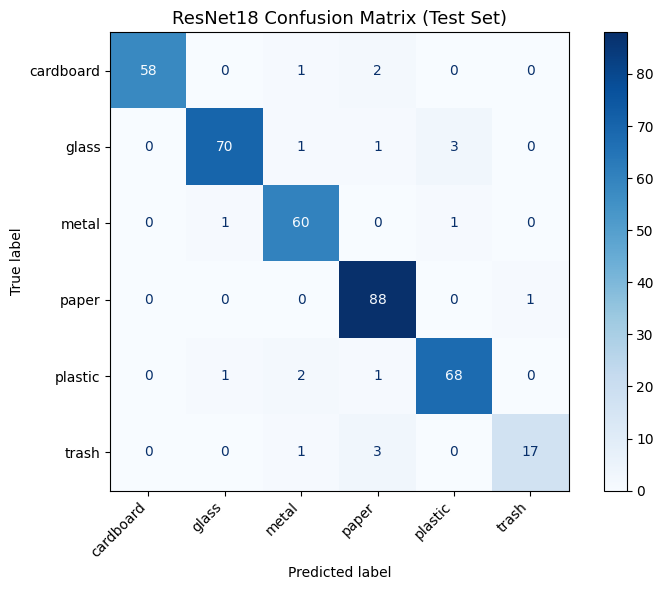

[[58  0  1  2  0  0]
 [ 0 70  1  1  3  0]
 [ 0  1 60  0  1  0]
 [ 0  0  0 88  0  1]
 [ 0  1  2  1 68  0]
 [ 0  0  1  3  0 17]]


In [10]:
cnn_cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
np.save(os.path.join(RESULTS_PATH, 'cnn_confusion_matrix.npy'), cnn_cm)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=CLASS_ORDER).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title('ResNet18 Confusion Matrix (Test Set)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'cnn_confusion_matrix.png'), dpi=150)
plt.show()

print(cnn_cm)

In [11]:
cnn_industrial = compute_industrial_metrics(cnn_cm, CLASS_ORDER)
cnn_industrial.to_csv(os.path.join(RESULTS_PATH, 'cnn_industrial_metrics.csv'), index=False)

print("ResNet18 Industrial Metrics:")
print(cnn_industrial.to_string(index=False))

cnn_macro = cnn_industrial[['Purity', 'Yield', 'Recovery']].mean()
print(f"\nMacro Purity:   {cnn_macro['Purity']:.4f}")
print(f"Macro Yield:    {cnn_macro['Yield']:.4f}")
print(f"Macro Recovery: {cnn_macro['Recovery']:.4f}")

ResNet18 Industrial Metrics:
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  58   0   3  1.0000 0.9508    0.9508
    glass  70   2   5  0.9722 0.9333    0.9091
    metal  60   5   2  0.9231 0.9677    0.8955
    paper  88   7   1  0.9263 0.9888    0.9167
  plastic  68   4   4  0.9444 0.9444    0.8947
    trash  17   1   4  0.9444 0.8095    0.7727

Macro Purity:   0.9517
Macro Yield:    0.9324
Macro Recovery: 0.8899


### 2. What happens to the glass/metal confusion

This is the cell finding 1 turns on. The counts below are the off-diagonal glass/metal
entries for every model in the project, computed from the committed confusion matrices so
they are the same numbers the README quotes, with the CNN added on the same test images.

In [12]:
# All five classical confusion matrices come off disk; only the CNN row is computed here.
CONFUSION_FILES = {
    'Logistic Regression': 'logreg_confusion_matrix.npy',
    'Linear SVC':          'linsvc_confusion_matrix.npy',
    'Random Forest':       'rf_confusion_matrix.npy',
    'MLP':                 'mlp_confusion_matrix.npy',
}

glass = CLASS_ORDER.index('glass')
metal = CLASS_ORDER.index('metal')

rows = []
for name, filename in CONFUSION_FILES.items():
    cm = np.load(os.path.join(RESULTS_PATH, filename))
    rows.append({
        'Model':          name,
        'glass as metal': int(cm[glass, metal]),
        'metal as glass': int(cm[metal, glass]),
        'Pair total':     int(cm[glass, metal] + cm[metal, glass]),
        'Total errors':   int(cm.sum() - np.trace(cm)),
    })

rows.append({
    'Model':          'ResNet18 (reference)',
    'glass as metal': int(cnn_cm[glass, metal]),
    'metal as glass': int(cnn_cm[metal, glass]),
    'Pair total':     int(cnn_cm[glass, metal] + cnn_cm[metal, glass]),
    'Total errors':   int(cnn_cm.sum() - np.trace(cnn_cm)),
})

glass_metal = pd.DataFrame(rows)
glass_metal['Share of errors'] = (
    glass_metal['Pair total'] / glass_metal['Total errors']
).round(3)
glass_metal.to_csv(os.path.join(RESULTS_PATH, 'glass_metal_confusion.csv'), index=False)

print("Glass/metal off-diagonal on the same 380 test images:\n")
print(glass_metal.to_string(index=False))

Glass/metal off-diagonal on the same 380 test images:

               Model  glass as metal  metal as glass  Pair total  Total errors  Share of errors
 Logistic Regression               7              14          21           118            0.178
          Linear SVC              11              14          25           125            0.200
       Random Forest               8               8          16            80            0.200
                 MLP              10               7          17            74            0.230
ResNet18 (reference)               1               1           2            19            0.105


In [13]:
# The pair is only 'the dominant error' if it is still the largest off-diagonal entry.
# For the CNN it is not, so the largest remaining confusions are listed explicitly.

off_diagonal = [
    (CLASS_ORDER[i], CLASS_ORDER[j], int(cnn_cm[i, j]))
    for i in range(len(CLASS_ORDER))
    for j in range(len(CLASS_ORDER))
    if i != j and cnn_cm[i, j] > 0
]
off_diagonal.sort(key=lambda r: -r[2])

print("ResNet18 off-diagonal entries, largest first:\n")
for true_class, predicted_class, count in off_diagonal:
    marker = '   <- the pair finding 1 is about' if {true_class, predicted_class} == {'glass', 'metal'} else ''
    print(f"  {count:>2}  {true_class} predicted as {predicted_class}{marker}")

ResNet18 off-diagonal entries, largest first:

   3  glass predicted as plastic
   3  trash predicted as paper
   2  cardboard predicted as paper
   2  plastic predicted as metal
   1  cardboard predicted as metal
   1  glass predicted as metal   <- the pair finding 1 is about
   1  glass predicted as paper
   1  metal predicted as glass   <- the pair finding 1 is about
   1  metal predicted as plastic
   1  paper predicted as trash
   1  plastic predicted as glass
   1  plastic predicted as paper
   1  trash predicted as metal


### The comparison table

The CNN row is labelled as a reference point wherever it is written to disk, so nothing
downstream can pick it up as a sixth candidate by accident.

In [14]:
comparison_all = pd.read_csv(os.path.join(RESULTS_PATH, 'master_comparison_all.csv'))

cnn_row = pd.DataFrame([{
    'Model':       'ResNet18 (reference)',
    'Accuracy':    round(cnn_accuracy, 4),
    'Weighted F1': round(cnn_f1_weighted, 4),
    'Macro F1':    round(cnn_f1_macro, 4),
    'Purity':      round(cnn_macro['Purity'], 4),
    'Yield':       round(cnn_macro['Yield'], 4),
    'Recovery':    round(cnn_macro['Recovery'], 4),
}])

comparison_with_cnn = pd.concat([comparison_all, cnn_row], ignore_index=True)
comparison_with_cnn.to_csv(
    os.path.join(RESULTS_PATH, 'master_comparison_with_cnn.csv'), index=False
)

print(comparison_with_cnn.to_string(index=False))

               Model  Accuracy  Weighted F1  Macro F1  Purity  Yield  Recovery
            Baseline    0.2450       0.1943    0.1749  0.2465 0.2152    0.1011
          Linear SVC    0.6711       0.6693    0.6620  0.6742 0.6540    0.5082
 Logistic Regression    0.6895       0.6879    0.6687  0.6841 0.6591    0.5141
       Random Forest    0.7895       0.7898    0.7747  0.7993 0.7612    0.6381
                 MLP    0.8053       0.8055    0.7914  0.7965 0.7876    0.6605
ResNet18 (reference)    0.9500       0.9498    0.9408  0.9517 0.9324    0.8899


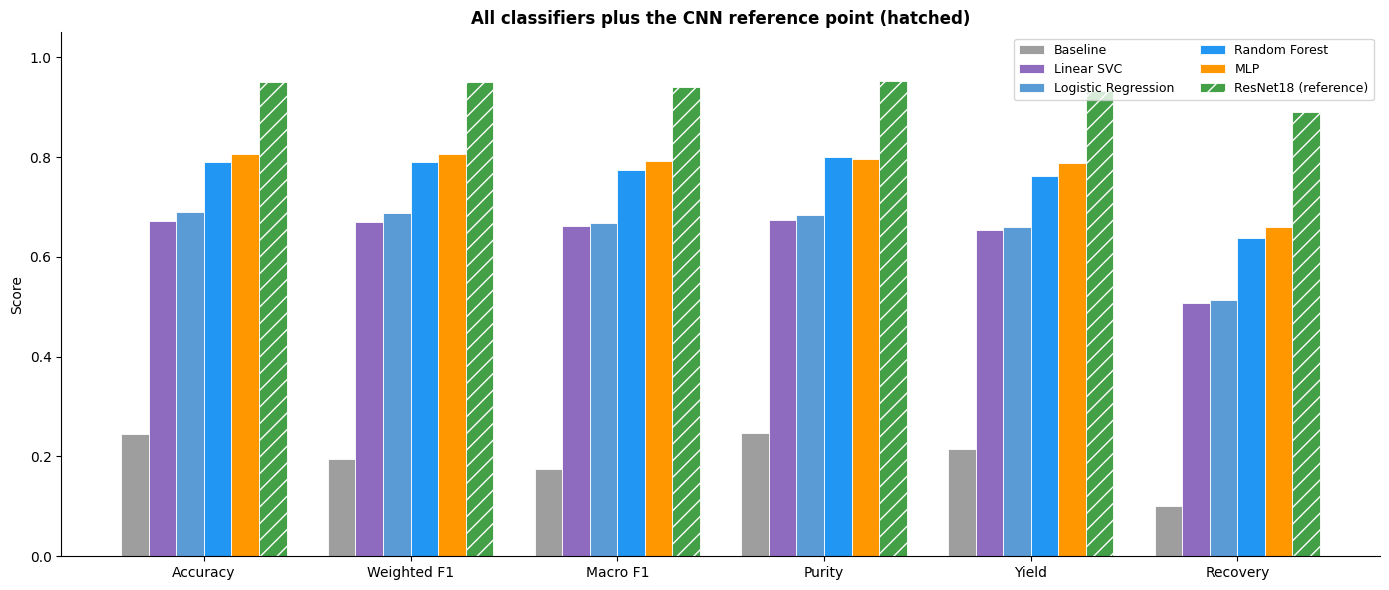

In [15]:
# Master comparison figure, with the reference row hatched so it does not read as a candidate.

metrics = ['Accuracy', 'Weighted F1', 'Macro F1', 'Purity', 'Yield', 'Recovery']
model_names = comparison_with_cnn['Model'].tolist()
is_reference = [name.endswith('(reference)') for name in model_names]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics))
width = 0.8 / len(model_names)
palette = ['#9e9e9e', '#8e6bbf', '#5b9bd5', '#2196F3', '#FF9800', '#43a047']

for i, name in enumerate(model_names):
    values = [comparison_with_cnn.loc[i, m] for m in metrics]
    ax.bar(
        x + i * width - 0.4 + width / 2, values, width,
        label=name, color=palette[i % len(palette)],
        hatch='//' if is_reference[i] else None,
        edgecolor='white', linewidth=0.6
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('All classifiers plus the CNN reference point (hatched)', fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'master_comparison_with_cnn.png'), dpi=150)
plt.show()

### 3. Robustness

The same four perturbation families at the same five severities, from the same
`src/perturbations.py` callables notebook 06 uses, applied to the raw image before the
network sees it. The RF and MLP curves are read from the committed
`robustness_results.json` rather than recomputed, so this is a comparison against the
published numbers and not against a fresh run of them.

In [16]:
cnn_robustness = {}

total = len(PERTURBATIONS) * len(SEVERITIES)
run = 0

for name in PERTURBATIONS:
    cnn_robustness[name] = {}

    for severity in SEVERITIES:
        run += 1
        loader = make_loader(test_idx, perturb_fn=make_perturbation(name, severity))
        pred, true = predict(model, loader)
        accuracy = accuracy_score(true, pred)
        cnn_robustness[name][severity] = float(accuracy)
        print(f"[{run:2d}/{total}] {name:<18} severity {severity}  accuracy {accuracy:.4f}")

[ 1/20] motion_blur        severity 1  accuracy 0.9421


[ 2/20] motion_blur        severity 2  accuracy 0.9184


[ 3/20] motion_blur        severity 3  accuracy 0.8763


[ 4/20] motion_blur        severity 4  accuracy 0.8395


[ 5/20] motion_blur        severity 5  accuracy 0.8132


...

[16/20] jpeg_compression   severity 1  accuracy 0.9474


[17/20] jpeg_compression   severity 2  accuracy 0.9342


[18/20] jpeg_compression   severity 3  accuracy 0.9342


[19/20] jpeg_compression   severity 4  accuracy 0.9158


[20/20] jpeg_compression   severity 5  accuracy 0.6184


In [17]:
classical = json.load(open(os.path.join(RESULTS_PATH, 'robustness_results.json')))
classical_curves = classical['robustness_results']

with open(os.path.join(RESULTS_PATH, 'cnn_robustness_results.json'), 'w') as f:
    json.dump({
        'clean_baseline': {
            'rf':  classical['clean_baseline']['rf'],
            'mlp': classical['clean_baseline']['mlp'],
            'cnn': float(cnn_accuracy),
        },
        'robustness_results': cnn_robustness,
    }, f, indent=2)

worst = pd.DataFrame([
    {
        'Perturbation':  PERTURBATION_TITLES[name],
        'Random Forest': classical_curves[name]['5'][0],
        'MLP':           classical_curves[name]['5'][1],
        'ResNet18':      cnn_robustness[name][5],
    }
    for name in PERTURBATIONS
]).round(3)

worst.to_csv(os.path.join(RESULTS_PATH, 'cnn_robustness_worst_case.csv'), index=False)

print("Accuracy at worst-case severity (chance on six classes is 0.167):\n")
print(worst.to_string(index=False))

Accuracy at worst-case severity (chance on six classes is 0.167):

        Perturbation  Random Forest   MLP  ResNet18
         Motion Blur          0.658 0.511     0.813
      Gaussian Noise          0.234 0.168     0.368
Brightness Reduction          0.418 0.358     0.492
    JPEG Compression          0.253 0.300     0.618


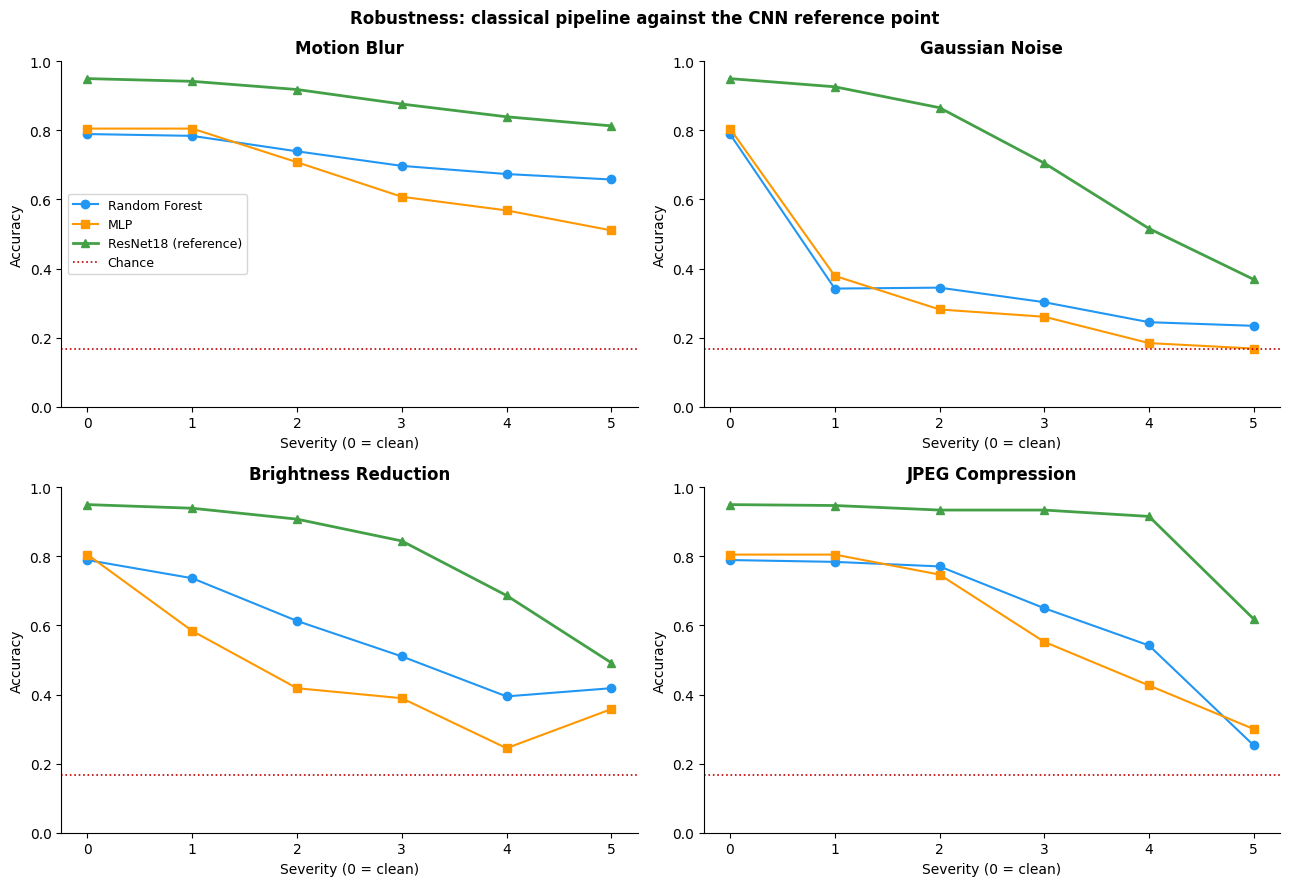

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, name in zip(axes.ravel(), PERTURBATIONS):
    severities = [0] + list(SEVERITIES)

    rf_curve  = [classical['clean_baseline']['rf']]  + [classical_curves[name][str(s)][0] for s in SEVERITIES]
    mlp_curve = [classical['clean_baseline']['mlp']] + [classical_curves[name][str(s)][1] for s in SEVERITIES]
    cnn_curve = [cnn_accuracy] + [cnn_robustness[name][s] for s in SEVERITIES]

    ax.plot(severities, rf_curve,  'o-', color='#2196F3', label='Random Forest')
    ax.plot(severities, mlp_curve, 's-', color='#FF9800', label='MLP')
    ax.plot(severities, cnn_curve, '^-', color='#43a047', label='ResNet18 (reference)', linewidth=2)
    ax.axhline(1 / len(CLASS_ORDER), color='#c00000', linestyle=':', linewidth=1.2, label='Chance')

    ax.set_title(PERTURBATION_TITLES[name], fontweight='bold')
    ax.set_xlabel('Severity (0 = clean)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(severities)
    ax.spines[['top', 'right']].set_visible(False)

axes[0, 0].legend(fontsize=9)
fig.suptitle('Robustness: classical pipeline against the CNN reference point', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'cnn_robustness_curves.png'), dpi=150)
plt.show()

### 4. Latency

CPU, because that is the hardware the 50 ms budget was derived against in notebook 07, and
because a plant buying a sorter prices the compute. GPU numbers are reported separately at
the end; they answer a different question, which is what the ceiling costs if you are willing
to put an accelerator on the line.

The structure mirrors notebook 07: preprocessing and the forward pass are timed separately,
warm-up calls are discarded, and the same batch sizes are swept. The run count per batch size
is scaled down as the batch grows so that each configuration does a comparable amount of
total work; a ResNet18 forward pass is three orders of magnitude more expensive than an RF
`predict` on one 122-dim row, so notebook 07's flat 50 runs would put batch 128 alone at
several minutes.

In [19]:
BATCH_SIZES  = [1, 8, 32, 128]
THREAD_COUNTS = [1, 2, 4, 8, os.cpu_count()]
DEFAULT_THREADS = torch.get_num_threads()

cpu_model = model.to('cpu').eval()

print(f"Logical CPUs: {os.cpu_count()}, torch default threads: {DEFAULT_THREADS}")


def runs_for(batch_size):
    """Roughly constant total work per configuration."""
    return max(5, int(400 / batch_size))


def time_forward(batch_tensor, runs, warmups=5):
    for _ in range(warmups):
        with torch.inference_mode():
            cpu_model(batch_tensor)

    times = []
    for _ in range(runs):
        start = time.perf_counter()
        with torch.inference_mode():
            cpu_model(batch_tensor)
        times.append(time.perf_counter() - start)

    return np.mean(times) * 1000, np.std(times) * 1000

Logical CPUs: 16, torch default threads: 8


In [20]:
# Image pool built the same way notebook 07 builds its benchmark pool: spread across the six
# classes, sorted filename order, decoded once so this measures the pipeline and not disk I/O.

POOL_SIZE = max(BATCH_SIZES)
per_class = -(-POOL_SIZE // len(CLASSES))

image_pool = []
for class_name in CLASSES:
    for path in list_class_images(DATASET_PATH, class_name)[:per_class]:
        image_pool.append(Image.open(path).convert('RGB'))
image_pool = image_pool[:POOL_SIZE]

pool_tensors = torch.stack([to_tensor(image) for image in image_pool])
sample_images = image_pool[:len(CLASSES)]

print(f"Image pool: {len(image_pool)} images, tensors {tuple(pool_tensors.shape)}")

Image pool: 128 images, tensors (128, 3, 224, 224)


In [21]:
# Preprocessing is PIL and numpy, so it does not respond to the torch thread count and is
# measured once. It is the CNN's analogue of the 18.2 ms feature extraction stage.

torch.set_num_threads(DEFAULT_THREADS)

preprocess_times = []
for image in sample_images:
    for _ in range(5):
        to_tensor(image)

    times = []
    for _ in range(100):
        start = time.perf_counter()
        to_tensor(image)
        times.append(time.perf_counter() - start)
    preprocess_times.append(np.mean(times))

preprocess_ms     = float(np.mean(preprocess_times) * 1000)
preprocess_std_ms = float(np.std(preprocess_times) * 1000)

print(f"Preprocessing (resize + normalise): {preprocess_ms:.3f} ms (+/- {preprocess_std_ms:.3f})")
print(f"For reference, HSV+LBP extraction is 18.152 ms (notebook 07).")

Preprocessing (resize + normalise): 2.561 ms (+/- 0.167)
For reference, HSV+LBP extraction is 18.152 ms (notebook 07).


In [22]:
# Single-image forward pass across thread counts. torch reuses one intra-op thread pool for
# the life of the process, so these are a within-run ordering rather than five independent
# benchmarks; the conclusion does not rest on the ordering, since every setting is far
# outside the budget.

thread_rows = []

for n_threads in THREAD_COUNTS:
    torch.set_num_threads(n_threads)
    per_image = [time_forward(pool_tensors[i:i + 1], runs=100)[0] for i in range(len(sample_images))]
    forward_ms = float(np.mean(per_image))
    e2e_ms = preprocess_ms + forward_ms

    thread_rows.append({
        'Threads':        n_threads,
        'Forward ms':     round(forward_ms, 3),
        'End-to-end ms':  round(e2e_ms, 3),
        'Within 50 ms?':  'yes' if e2e_ms <= LATENCY_TARGET_MS else 'no',
        'Items/min':      round(60000.0 / e2e_ms, 1),
    })
    print(f"threads {n_threads:>2}: forward {forward_ms:7.3f} ms, end-to-end {e2e_ms:7.3f} ms")

thread_table = pd.DataFrame(thread_rows)
best_threads = int(thread_table.loc[thread_table['End-to-end ms'].idxmin(), 'Threads'])

print()
print(thread_table.to_string(index=False))
print(f"\nFastest single-image configuration: {best_threads} threads")

threads  1: forward  48.641 ms, end-to-end  51.202 ms


threads  2: forward  28.164 ms, end-to-end  30.725 ms


threads  4: forward  19.361 ms, end-to-end  21.922 ms


threads  8: forward  17.765 ms, end-to-end  20.326 ms


threads 16: forward  20.592 ms, end-to-end  23.153 ms

 Threads  Forward ms  End-to-end ms Within 50 ms?  Items/min
       1      48.641         51.202            no     1171.8
       2      28.164         30.725           yes     1952.8
       4      19.361         21.922           yes     2737.0
       8      17.765         20.326           yes     2951.8
      16      20.592         23.153           yes     2591.5

Fastest single-image configuration: 8 threads


In [23]:
# Batched CPU throughput at the fastest single-image thread count.

torch.set_num_threads(best_threads)

batch_rows = []

for batch_size in BATCH_SIZES:
    batch = image_pool[:batch_size]
    runs = runs_for(batch_size)

    for _ in range(min(batch_size, 8)):
        to_tensor(batch[0])

    times = []
    for _ in range(runs):
        start = time.perf_counter()
        for image in batch:
            to_tensor(image)
        times.append(time.perf_counter() - start)
    preprocess_item = float(np.mean(times) * 1000 / batch_size)

    forward_total, _ = time_forward(pool_tensors[:batch_size], runs=runs)
    forward_item = forward_total / batch_size
    e2e_item = preprocess_item + forward_item

    batch_rows.append({
        'Batch':             batch_size,
        'Preprocess ms/item': round(preprocess_item, 3),
        'Forward ms/item':    round(forward_item, 3),
        'End-to-end ms/item': round(e2e_item, 3),
        'Items/min':          round(60000.0 / e2e_item, 1),
        'Clears 1200/min?':   'yes' if 60000.0 / e2e_item >= TARGET_ITEMS_PER_MIN else 'no',
    })
    print(f"batch {batch_size:>4} ({runs:>3} runs): {e2e_item:7.3f} ms/item, "
          f"{60000.0 / e2e_item:7.1f} items/min")

batch_table = pd.DataFrame(batch_rows)
print()
print(batch_table.to_string(index=False))

batch    1 (400 runs):  20.195 ms/item,  2971.1 items/min


batch    8 ( 50 runs):  12.960 ms/item,  4629.7 items/min


batch   32 ( 12 runs):  13.394 ms/item,  4479.7 items/min


batch  128 (  5 runs):  12.359 ms/item,  4854.8 items/min

 Batch  Preprocess ms/item  Forward ms/item  End-to-end ms/item  Items/min Clears 1200/min?
     1               2.752           17.443              20.195     2971.1              yes
     8               2.579           10.381              12.960     4629.7              yes
    32               2.592           10.802              13.394     4479.7              yes
   128               2.593            9.766              12.359     4854.8              yes


In [24]:
# GPU, reported separately. Preprocessing stays on the CPU, so the GPU column changes the
# forward pass only and the preprocessing floor still applies.

gpu_rows = []
gpu_name = None

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_model = model.to('cuda').eval()

    for batch_size in BATCH_SIZES:
        batch_tensor = pool_tensors[:batch_size].cuda()
        runs = runs_for(batch_size)

        for _ in range(10):
            with torch.inference_mode():
                gpu_model(batch_tensor)
        torch.cuda.synchronize()

        times = []
        for _ in range(runs):
            start = time.perf_counter()
            with torch.inference_mode():
                gpu_model(batch_tensor)
            torch.cuda.synchronize()
            times.append(time.perf_counter() - start)

        forward_item = float(np.mean(times) * 1000 / batch_size)
        gpu_rows.append({
            'Batch':              batch_size,
            'Forward ms/item':    round(forward_item, 4),
            'End-to-end ms/item': round(preprocess_ms + forward_item, 3),
            'Items/min':          round(60000.0 / (preprocess_ms + forward_item), 1),
        })

    model.to('cpu')
    gpu_table = pd.DataFrame(gpu_rows)
    print(f"GPU: {gpu_name}\n")
    print(gpu_table.to_string(index=False))
else:
    print("No CUDA device available; the GPU column is skipped.")

torch.set_num_threads(DEFAULT_THREADS)

GPU: NVIDIA GeForce RTX 5060

 Batch  Forward ms/item  End-to-end ms/item  Items/min
     1           3.8249               6.386     9395.9
     8           0.4881               3.049    19679.0
    32           0.4174               2.978    20145.8
   128           0.4205               2.981    20125.0


In [25]:
latency_results = {
    'device_note':            'CPU timings are the comparison; see notebook 07 for the classical pipeline',
    'preprocess_ms':          preprocess_ms,
    'preprocess_std_ms':      preprocess_std_ms,
    'default_threads':        DEFAULT_THREADS,
    'logical_cpus':           os.cpu_count(),
    'best_thread_count':      best_threads,
    'cpu_threads':            thread_rows,
    'cpu_batched':            batch_rows,
    'gpu_name':               gpu_name,
    'gpu_forward':            gpu_rows,
    'latency_target_ms':      LATENCY_TARGET_MS,
    'target_items_per_min':   TARGET_ITEMS_PER_MIN,
}

with open(os.path.join(RESULTS_PATH, 'cnn_latency_results.json'), 'w') as f:
    json.dump(latency_results, f, indent=2)

batch_table.to_csv(os.path.join(RESULTS_PATH, 'cnn_batch_throughput.csv'), index=False)

print("Saved cnn_latency_results.json and cnn_batch_throughput.csv")

Saved cnn_latency_results.json and cnn_batch_throughput.csv


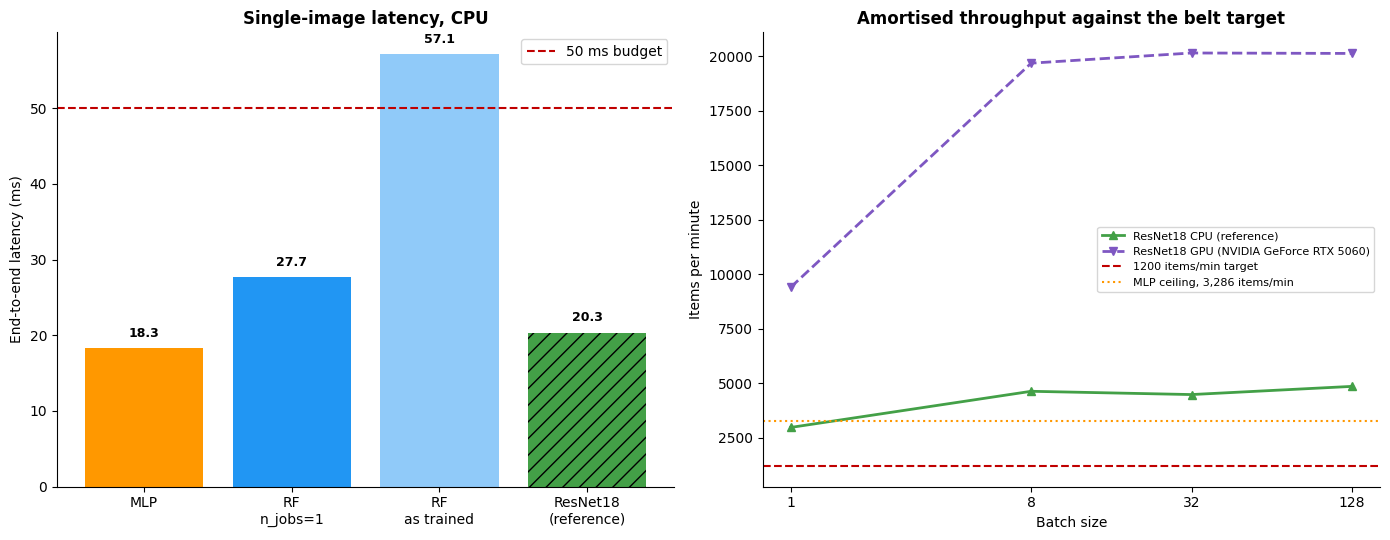

In [26]:
# Two panels: single-image end-to-end latency against the 50 ms budget, and per-item
# throughput against the 1,200 items/min target.

classical_latency = json.load(open(os.path.join(RESULTS_PATH, 'latency_results.json')))
thread_latency    = json.load(open(os.path.join(RESULTS_PATH, 'thread_count_results.json')))

cnn_best_e2e = float(thread_table['End-to-end ms'].min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

labels = ['MLP', 'RF\nn_jobs=1', 'RF\nas trained', 'ResNet18\n(reference)']
values = [
    classical_latency['mlp_e2e_ms'],
    thread_latency['rf_by_n_jobs']['1']['total_mean_ms'],
    classical_latency['rf_e2e_ms'],
    cnn_best_e2e,
]
colours = ['#FF9800', '#2196F3', '#90caf9', '#43a047']

bars = axes[0].bar(labels, values, color=colours)
bars[-1].set_hatch('//')
axes[0].axhline(LATENCY_TARGET_MS, color='#c00000', linestyle='--', linewidth=1.5,
                label=f'{LATENCY_TARGET_MS} ms budget')
axes[0].set_ylabel('End-to-end latency (ms)')
axes[0].set_title('Single-image latency, CPU', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)
for bar, value in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 1.5, f'{value:.1f}',
                 ha='center', fontweight='bold', fontsize=9)

axes[1].plot(batch_table['Batch'], batch_table['Items/min'], '^-',
             color='#43a047', linewidth=2, label='ResNet18 CPU (reference)')
if gpu_rows:
    axes[1].plot([r['Batch'] for r in gpu_rows], [r['Items/min'] for r in gpu_rows], 'v--',
                 color='#7e57c2', linewidth=2, label=f'ResNet18 GPU ({gpu_name})')
axes[1].axhline(TARGET_ITEMS_PER_MIN, color='#c00000', linestyle='--', linewidth=1.5,
                label=f'{TARGET_ITEMS_PER_MIN} items/min target')
axes[1].axhline(3286, color='#FF9800', linestyle=':', linewidth=1.5,
                label='MLP ceiling, 3,286 items/min')
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(BATCH_SIZES)
axes[1].set_xticklabels(BATCH_SIZES)
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Items per minute')
axes[1].set_title('Amortised throughput against the belt target', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'cnn_latency_throughput.png'), dpi=150)
plt.show()

### Summary

The three axes, together, on the same test partition.

In [27]:
summary = pd.DataFrame([
    {
        'Axis':     'Clean accuracy',
        'RF':       f"{classical['clean_baseline']['rf']:.4f}",
        'MLP':      f"{classical['clean_baseline']['mlp']:.4f}",
        'ResNet18': f"{cnn_accuracy:.4f}",
    },
    {
        'Axis':     'Glass/metal off-diagonal',
        'RF':       str(int(rf_cm_committed[glass, metal] + rf_cm_committed[metal, glass])),
        'MLP':      str(int(np.load(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'))[glass, metal]
                            + np.load(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'))[metal, glass])),
        'ResNet18': str(int(cnn_cm[glass, metal] + cnn_cm[metal, glass])),
    },
    {
        'Axis':     'Worst-case motion blur',
        'RF':       f"{classical_curves['motion_blur']['5'][0]:.3f}",
        'MLP':      f"{classical_curves['motion_blur']['5'][1]:.3f}",
        'ResNet18': f"{cnn_robustness['motion_blur'][5]:.3f}",
    },
    {
        'Axis':     'Mild Gaussian noise (severity 1)',
        'RF':       f"{classical_curves['gaussian_noise']['1'][0]:.3f}",
        'MLP':      f"{classical_curves['gaussian_noise']['1'][1]:.3f}",
        'ResNet18': f"{cnn_robustness['gaussian_noise'][1]:.3f}",
    },
    {
        'Axis':     'Single-image CPU latency (ms)',
        'RF':       f"{classical_latency['rf_e2e_ms']:.1f}",
        'MLP':      f"{classical_latency['mlp_e2e_ms']:.1f}",
        'ResNet18': f"{cnn_best_e2e:.1f}",
    },
])

print(summary.to_string(index=False))
print(f"\nBudget: {LATENCY_TARGET_MS} ms single-image, {TARGET_ITEMS_PER_MIN} items/min batched.")

                            Axis     RF    MLP ResNet18
                  Clean accuracy 0.7895 0.8053   0.9500
        Glass/metal off-diagonal     16     17        2
          Worst-case motion blur  0.658  0.511    0.813
Mild Gaussian noise (severity 1)  0.342  0.379    0.926
   Single-image CPU latency (ms)   57.1   18.3     20.3

Budget: 50 ms single-image, 1200 items/min batched.
